# Huntington's Disease — Disease Stage Prediction

End-to-end pipeline: data preprocessing, EDA/visualization, feature engineering, class balancing (SMOTETomek), and model comparison (TabNet vs RandomForest).

*Rebuilt from the project document. Run cells top to bottom.*

## 1. Imports & Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [ ]:
df = pd.read_csv('Huntington_Disease_Dataset.csv')


## 2. Data Preprocessing

In [ ]:
# Step 1 to remove duplicate from dataset
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

In [ ]:
# Step 2 to drop unnecessary column because it effect the functionality of data and also make it difficult to train the model
df.drop(columns=['Patient_ID', 'Random_Protein_Sequence', 'Random_Gene_Sequence'], inplace=True)
print("Remaining columns:", df.columns.tolist())

In [ ]:
# step 4 handle and remove null value
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# step 5 is to convert object into numeric value by using label encoding because there are multiple object value so we use loop for it
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
# step 6 is standardization
cols_to_scale = [
    'Age', 'HTT_CAG_Repeat_Length', 'Chorea_Score',
    'Brain_Volume_Loss', 'Functional_Capacity',
    'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level'
]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.head()

## 3. Exploratory Data Analysis & Visualization

In [ ]:
# step 7 is correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap='pink', fmt='.2f')
plt.title('Correlation Matrix Huntington Disease Dataset')
plt.xticks(rotation=30, ha='right')
plt.show()

In [ ]:
# step 8 is to remove outlier
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Chorea_Score'])
plt.title('Chorea Score Before Outlier Removal')
plt.show()

Q1 = df['Chorea_Score'].quantile(0.25)
Q3 = df['Chorea_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Chorea_Score'] >= lower_bound) & (df['Chorea_Score'] <= upper_bound)]

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Chorea_Score'])
plt.title('Chorea Score After Outlier Removal')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_20832\1010691443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Disease_Stage', y='HTT_CAG_Repeat_Length', data=df, palette='muted', inner='quartile')


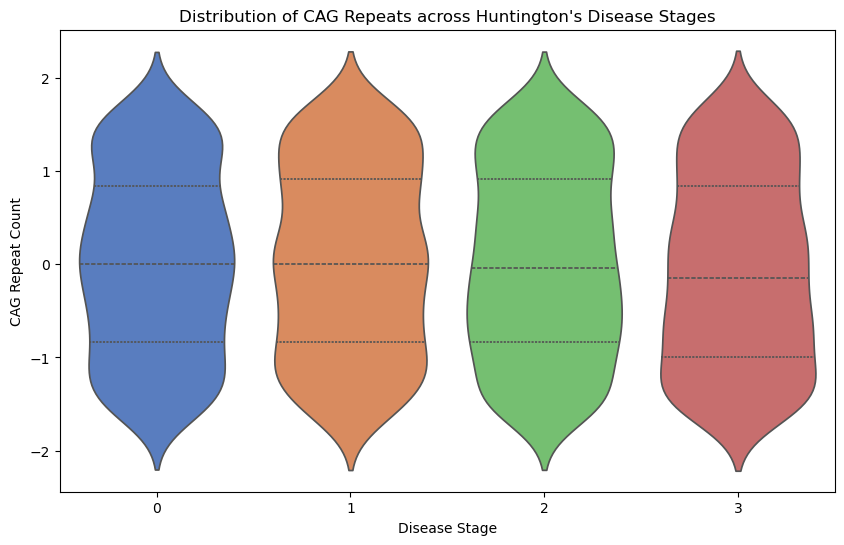

In [10]:
# violin plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.violinplot(x='Disease_Stage', y='HTT_CAG_Repeat_Length', data=df, palette='muted', inner='quartile')
plt.title("Distribution of CAG Repeats across Huntington's Disease Stages")
plt.xlabel('Disease Stage')
plt.ylabel('CAG Repeat Count')
plt.show()

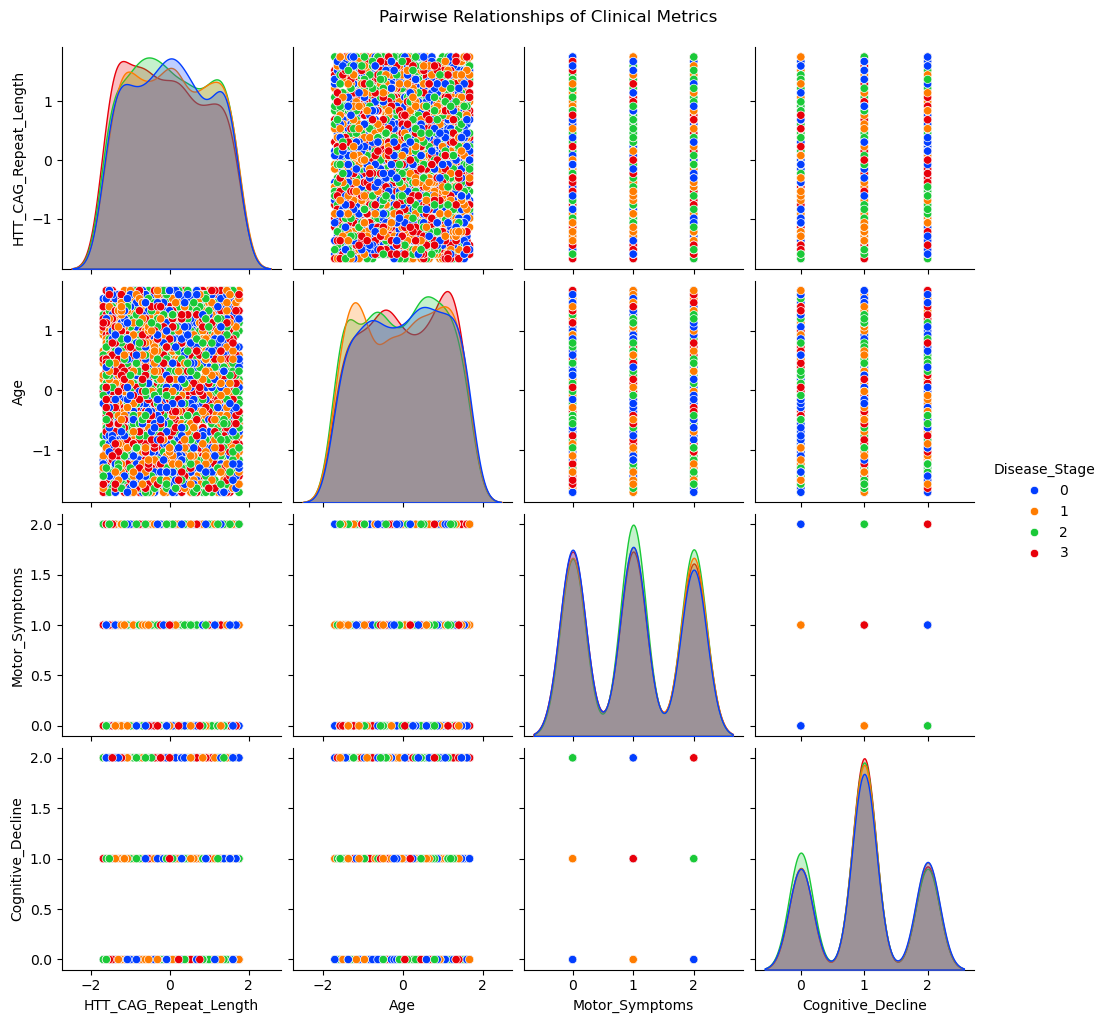

In [11]:
# pair plot
import seaborn as sns
import matplotlib.pyplot as plt
features = ['HTT_CAG_Repeat_Length', 'Age', 'Motor_Symptoms', 'Cognitive_Decline', 'Disease_Stage']
sns.pairplot(df[features], hue='Disease_Stage', palette='bright', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Clinical Metrics', y=1.02)
plt.show()

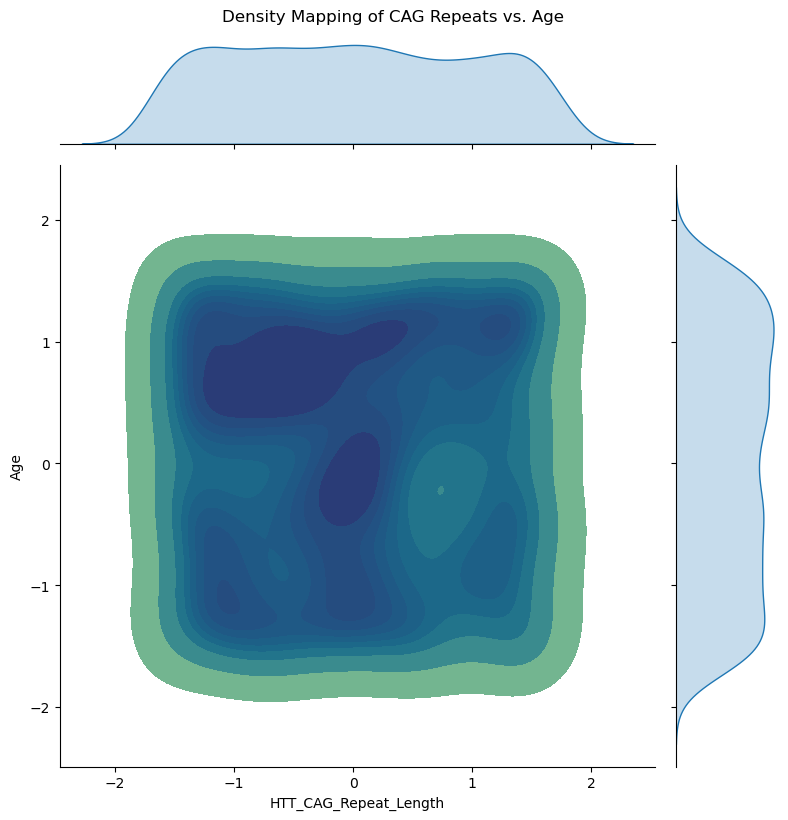

In [12]:
# KDE
import seaborn as sns
import matplotlib.pyplot as plt
sns.jointplot(x='HTT_CAG_Repeat_Length', y='Age', data=df, kind='kde', cmap='crest', fill=True, height=8)
plt.gcf().suptitle('Density Mapping of CAG Repeats vs. Age', y=1.02)
plt.show()

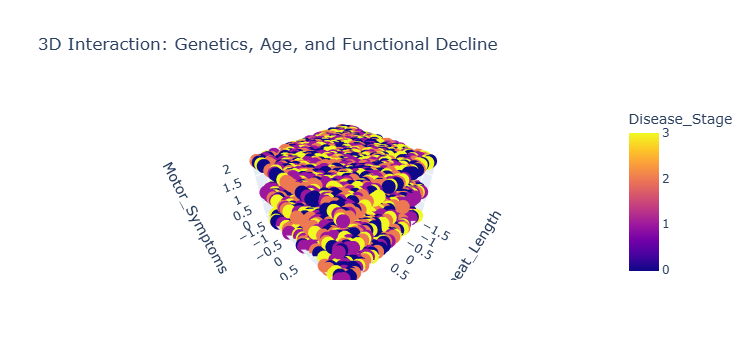

In [13]:
# 3D scatter
import plotly.express as px
fig = px.scatter_3d(df, x='HTT_CAG_Repeat_Length', y='Age', z='Motor_Symptoms',
                    color='Disease_Stage',
                    title='3D Interaction: Genetics, Age, and Functional Decline')
fig.show()

## 4. ROC Curve — Stage 3 vs. Rest (Logistic Regression)

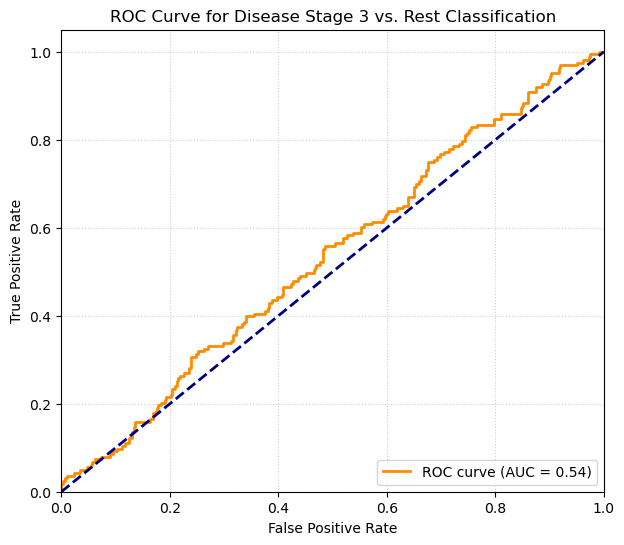

In [14]:
# ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
from imblearn.combine import SMOTETomek

X = df.drop(columns=['Disease_Stage'])
y = df['Disease_Stage']
balance = SMOTETomek(random_state=42)
X, y = balance.fit_resample(X, y)

y_binary_target = (y == 3).astype(int)
X_train, X_test, y_train_binary, y_test_binary = train_test_split(
    X, y_binary_target, test_size=0.3, random_state=42, stratify=y_binary_target
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train_binary)
y_probs = model.predict_proba(X_test)[:, 1]
y_test = y_test_binary
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Disease Stage 3 vs. Rest Classification')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 5. Feature Engineering (Binning)

In [15]:
# step 9 (Extra step) Transformation & Feature Engineering (Binning) — this step groups the age into sub groups so it will be helpful for our machine to train
age_bins = [0, 35, 55, 100]          # age grouping
age_labels = ['Young Adult', 'Adult', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

cag_bins = [0, 40, 50, 150]          # cag risk
cag_labels = ['Normal/Borderline', 'High Risk', 'Severe Risk']
df['CAG_Risk_Tier'] = pd.cut(df['HTT_CAG_Repeat_Length'], bins=cag_bins, labels=cag_labels)

from sklearn.preprocessing import LabelEncoder   # created groups into numeric values
le_transform = LabelEncoder()
df['Age_Group'] = le_transform.fit_transform(df['Age_Group'])
df['CAG_Risk_Tier'] = le_transform.fit_transform(df['CAG_Risk_Tier'])

print("Data Transformation successful! New features created.")
df[['Age', 'Age_Group', 'HTT_CAG_Repeat_Length', 'CAG_Risk_Tier']].head()

Data Transformation successful! New features created.


,Age,Age_Group,HTT_CAG_Repeat_Length,CAG_Risk_Tier
0,-1.637068,1,0.761300,0
1,-1.502153,1,-1.449477,1
2,0.926318,0,-1.525711,1
3,0.723945,0,-0.534673,1
4,-0.827578,1,-0.687140,1


## 6. Class Imbalance Handling (SMOTETomek)

In [16]:
# step 10 handle class imbalance using SMOTETomek
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTETomek  # Import SMOTETomek

print("Target Distribution Before Balancing:")
print(df['Disease_Stage'].value_counts())

X = df.drop(columns=['Disease_Stage'])
y = df['Disease_Stage']

# Check data types and handle mixed types
print("Data types in features:")
print(X.dtypes)

# Convert all features to numeric, handling any non-numeric values
# Create a copy to avoid modifying original data
X_processed = X.copy()

# Handle categorical columns by encoding them
for column in X_processed.columns:
    if X_processed[column].dtype == 'object':  # If column contains strings
        # Create a new LabelEncoder for each column to avoid conflicts
        le_column = LabelEncoder()
        # Fill any missing values first
        X_processed[column] = X_processed[column].fillna('Unknown')
        # Encode categorical variables to numeric
        X_processed[column] = le_column.fit_transform(X_processed[column].astype(str))
    else:
        # For numeric columns, fill missing values with median
        # Convert to numeric first to handle any string numbers
        X_processed[column] = pd.to_numeric(X_processed[column], errors='coerce')
        X_processed[column] = X_processed[column].fillna(X_processed[column].median())

# Ensure all data is numeric
X_processed = X_processed.astype(float)

# Now apply SMOTETomek
balance = SMOTETomek(random_state=42)
X_balanced, y_balanced = balance.fit_resample(X_processed, y)

print("\nTarget Distribution After Balancing:")
print(pd.Series(y_balanced).value_counts())

# Recreate the balanced dataframe
df_balanced = pd.concat([pd.DataFrame(X_balanced, columns=X_processed.columns), 
                        pd.Series(y_balanced, name='Disease_Stage')], axis=1)
df_balanced.to_csv('Huntington_Disease_Prediction_Updated.csv', index=False)

Target Distribution Before Balancing:
Disease_Stage
2    792
1    768
3    766
0    762
Name: count, dtype: int64
Data types in features:
Age                          float64
Sex                            int64
Family_History                 int64
HTT_CAG_Repeat_Length        float64
Motor_Symptoms                 int64
Cognitive_Decline              int64
Chorea_Score                 float64
Brain_Volume_Loss            float64
Functional_Capacity          float64
Gene_Mutation_Type             int64
HTT_Gene_Expression_Level    float64
Protein_Aggregation_Level    float64
Gene/Factor                    int64
Chromosome_Location            int64
Function                       int64
Effect                         int64
Category                       int64
Age_Group                      int64
CAG_Risk_Tier                  int64
dtype: object

Target Distribution After Balancing:
Disease_Stage
1    559
0    555
3    547
2    517
Name: count, dtype: int64


## 7. TabNet Classifier (Main Model)

In [17]:
!pip install pytorch-tabnet

In [20]:
# Import required libraries including TabNetClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier  # Added missing import

X_clean = X.fillna(X.mean())  # Fill with mean for numerical columns
# y_clean = y.fillna(y.mode()[0])  # Fill with mode for target variable

print(f"Data shape after cleaning - X: {X_clean.shape}, y: {y_clean.shape}")

# Convert to numeric data types before converting to numpy arrays
# This ensures all data is numeric and compatible with TabNet
X_clean_numeric = X_clean.select_dtypes(include=[np.number])  # Select only numeric columns
if X_clean_numeric.shape[1] < X_clean.shape[1]:
    print(f"Warning: Dropped {X_clean.shape[1] - X_clean_numeric.shape[1]} non-numeric columns")

X_np = X_clean_numeric.values.astype(np.float32)  # Ensure float32 type

# FIXED: Encode categorical target variable to numeric labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_clean)  # Convert categorical labels to integers
y_np = y_encoded.astype(np.int64)  # Now safe to convert to int64

# Print label mapping for reference
print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_np, y_np, test_size=0.3, random_state=42, stratify=y_np
)

print(f"Shape of X_train_tab: {X_train_tab.shape}")
print(f"Shape of y_train_tab: {y_train_tab.shape}")
print(f"Shape of X_test_tab: {X_test_tab.shape}")
print(f"Shape of y_test_tab: {y_test_tab.shape}")

# Verify no NaN values remain in training data - Fixed to work with numeric arrays
print(f"NaN in X_train_tab: {np.isnan(X_train_tab).sum()}")
print(f"NaN in y_train_tab: {np.isnan(y_train_tab).sum()}")

# Now TabNetClassifier is properly imported and can be used
tabnet_classifier = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.5,
    n_independent=2, n_shared=2,
    lambda_sparse=1e-3, seed=42, verbose=0
)

tabnet_classifier.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    max_epochs=100, patience=20,
    batch_size=1024, virtual_batch_size=128
)

print("TabNet model training complete.")

Data shape after cleaning - X: (3088, 19), y: (3088,)
Label mapping: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3}
Shape of X_train_tab: (2161, 19)
Shape of y_train_tab: (2161,)
Shape of X_test_tab: (927, 19)
Shape of y_test_tab: (927,)
NaN in X_train_tab: 0
NaN in y_train_tab: 0

Early stopping occurred at epoch 21 with best_epoch = 1 and best_val_0_accuracy = 0.26969


C:\Users\DELL\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



TabNet model training complete.


TabNet Classifier Accuracy: 0.2697
TabNet Classifier Precision: 0.2842
TabNet Classifier Recall: 0.2697
TabNet Classifier F1-Score: 0.2548

Confusion Matrix:
[[36 83 27 83]
 [24 97 27 82]
 [23 96 33 86]
 [30 95 21 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.16      0.21       229
           1       0.26      0.42      0.32       230
           2       0.31      0.14      0.19       238
           3       0.25      0.37      0.30       230

    accuracy                           0.27       927
   macro avg       0.28      0.27      0.26       927
weighted avg       0.28      0.27      0.25       927



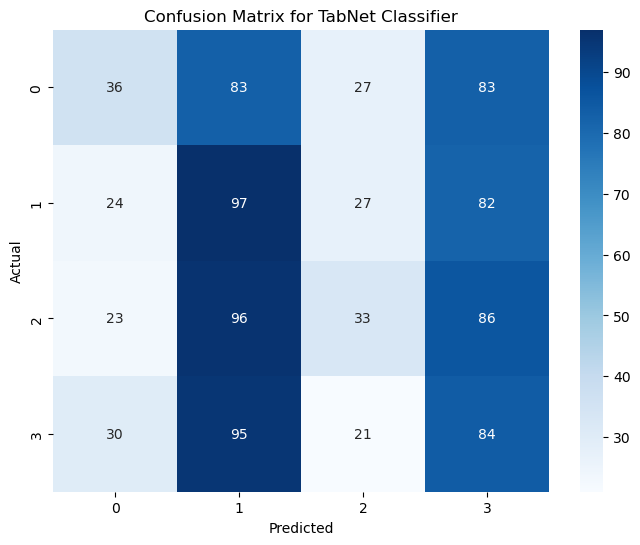

In [22]:
# Import necessary libraries for metrics and visualization
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Your original code with the required imports added
y_pred_tab = tabnet_classifier.predict(X_test_tab)
accuracy = accuracy_score(y_test_tab, y_pred_tab)
precision = precision_score(y_test_tab, y_pred_tab, average='weighted')
recall = recall_score(y_test_tab, y_pred_tab, average='weighted')
f1 = f1_score(y_test_tab, y_pred_tab, average='weighted')
conf_matrix = confusion_matrix(y_test_tab, y_pred_tab)
class_report = classification_report(y_test_tab, y_pred_tab)

print(f"TabNet Classifier Accuracy: {accuracy:.4f}")
print(f"TabNet Classifier Precision: {precision:.4f}")
print(f"TabNet Classifier Recall: {recall:.4f}")
print(f"TabNet Classifier F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for TabNet Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. RandomForest Classifier (Comparison Baseline)

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_tab, y_train_tab)
print("RandomForest Classifier training complete.")

RandomForest Classifier training complete.


RandomForest Classifier Accuracy: 0.2589
RandomForest Classifier Precision: 0.2596
RandomForest Classifier Recall: 0.2589
RandomForest Classifier F1-Score: 0.2591

Confusion Matrix (RandomForest Classifier):
[[58 57 63 51]
 [52 61 67 50]
 [58 68 58 54]
 [54 62 51 63]]

Classification Report (RandomForest Classifier):
              precision    recall  f1-score   support

           0       0.26      0.25      0.26       229
           1       0.25      0.27      0.26       230
           2       0.24      0.24      0.24       238
           3       0.29      0.27      0.28       230

    accuracy                           0.26       927
   macro avg       0.26      0.26      0.26       927
weighted avg       0.26      0.26      0.26       927



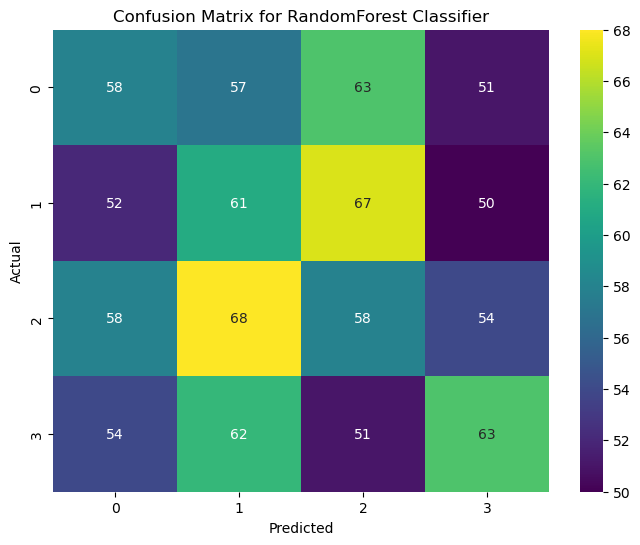

In [24]:

y_pred_rf = rf_classifier.predict(X_test_tab)
accuracy_rf = accuracy_score(y_test_tab, y_pred_rf)
precision_rf = precision_score(y_test_tab, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test_tab, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test_tab, y_pred_rf, average='weighted')
conf_matrix_rf = confusion_matrix(y_test_tab, y_pred_rf)
class_report_rf = classification_report(y_test_tab, y_pred_rf)
print(f"RandomForest Classifier Accuracy: {accuracy_rf:.4f}")
print(f"RandomForest Classifier Precision: {precision_rf:.4f}")
print(f"RandomForest Classifier Recall: {recall_rf:.4f}")
print(f"RandomForest Classifier F1-Score: {f1_rf:.4f}")
print("\nConfusion Matrix (RandomForest Classifier):")
print(conf_matrix_rf)
print("\nClassification Report (RandomForest Classifier):")
print(class_report_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix for RandomForest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()